# L1 & L2 Normalization

### 1. What kind of scaling is this?
Normalization is a **row-wise** scaling technique. This is the key thing that separates
it from StandardScaler / MinMaxScaler, which are **column-wise (feature-wise)** —
each feature is scaled independently using stats (mean, std, min, max) computed
*across all rows*.

Normalization instead looks at **one row (one data point/vector) at a time**, and
rescales all its feature values together, based only on that row.

*(Minor correction: "Multivariate scaling Technique" isn't a standard term you'll
find in textbooks — the correct contrast to use in an interview is
**row-wise normalization vs. column-wise/feature-wise scaling**.)*

### 2. Effect on individual features
Because scaling happens row-by-row, an individual feature's own distribution across
the dataset **is not preserved** — you're not making feature 1 have mean 0 across
all rows the way StandardScaler does. Instead, you're just making sure each **row
(vector)** has a consistent magnitude.

### 3. L2 Normalization

For a row with features f1=5, f2=15:

1. Compute the **L2 norm** (Euclidean length of the vector):
   `||v||₂ = sqrt(5² + 15²) = sqrt(250) ≈ 15.81`
2. Divide every feature in that row by this norm:
   `f1_new = 5 / 15.81 ≈ 0.316`, `f2_new = 15 / 15.81 ≈ 0.949`

**Result:** the transformed vector now has length exactly 1 — it sits on the unit
circle (or unit hypersphere in higher dimensions). This means you've kept the
**direction** of the vector, but thrown away its **magnitude**.

**L2 Says**: "I don't care about how long the arrow is. I only care about which direction it points."

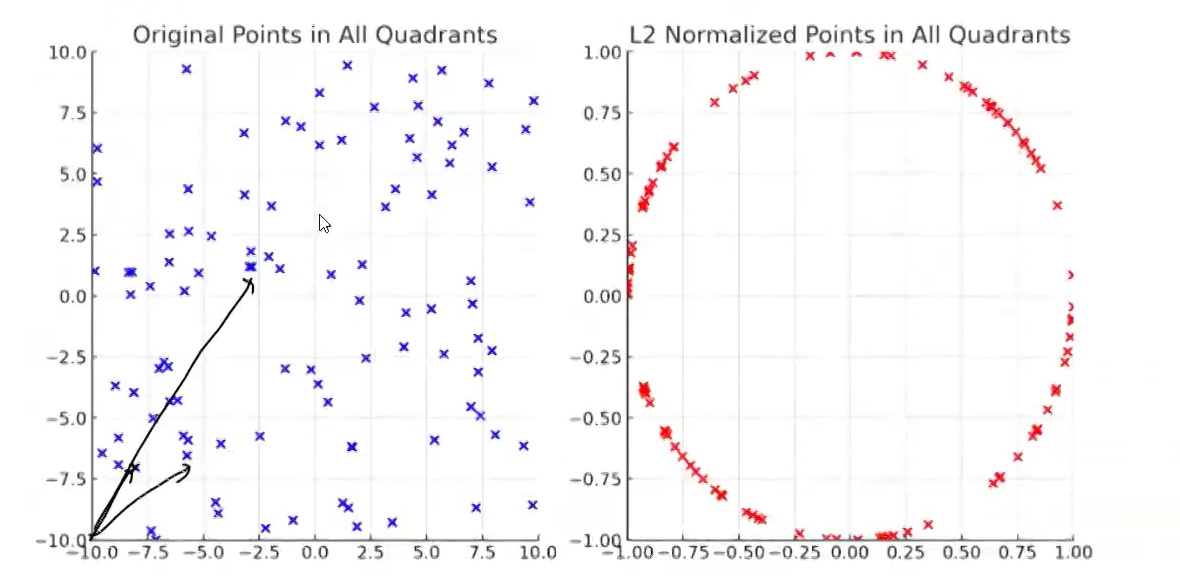

### 4. L1 Normalization

Same idea, but use the **Manhattan distance** (sum of absolute values) instead of
Euclidean distance:
`||v||₁ = |5| + |15| = 20`
`f1_new = 5/20 = 0.25`, `f2_new = 15/20 = 0.75`

**Result:** the transformed feature values now **sum to 1** — this is why L1
normalization is often used when you want values that behave like proportions
or a probability distribution.

**L1 Says** : "I don't care about the total magnitude. I care about how the total is distributed among the components."

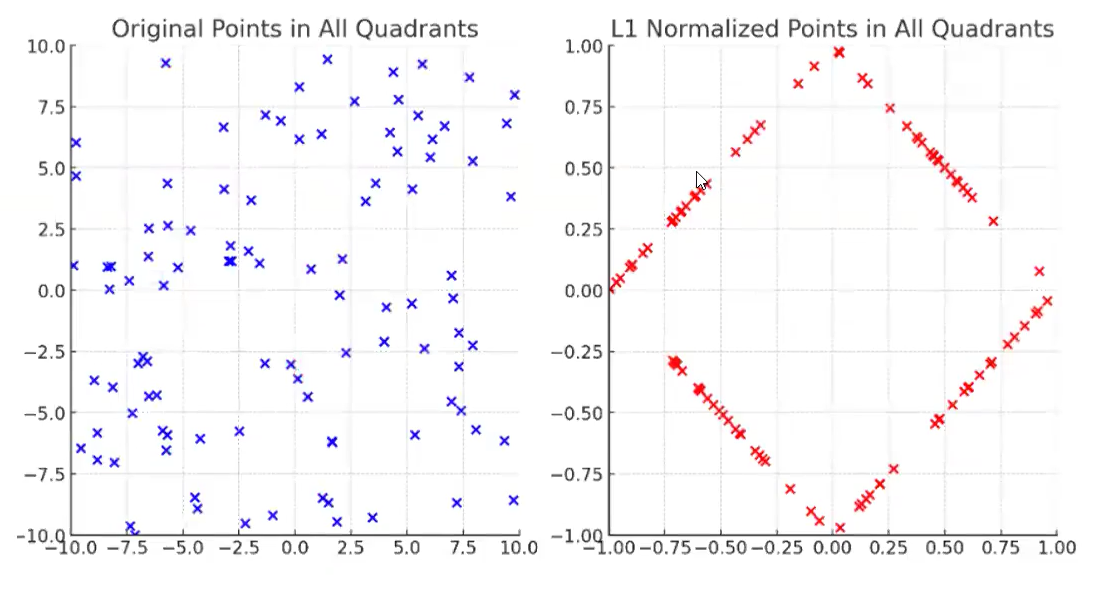

### 5. L1 vs L2 — when to pick which
| | L2 | L1 |
|---|---|---|
| Preserves | **Direction** (unit length = 1) | **Proportions** (values sum to 1) |
| Sensitivity to outliers | More sensitive (squares amplify large values) | More robust |
| Common use | Cosine similarity, embeddings | Sparse/high-dimensional data (e.g. text/TF-IDF), when you want proportion-like features |

### 6. Use Cases
Normalization isn't tied to a specific ML algorithm — it's used wherever the
operation that follows cares about **vector direction/relationships**, not the
raw feature values. Common examples:
- Generating and comparing **embedding vectors** (so magnitude differences don't
  distort similarity)
- **Recommender systems / ranking**, where **cosine similarity** is used —
  and cosine similarity between two L2-normalized vectors is just their dot product
- **Text data** (TF-IDF vectors), since document length shouldn't dominate similarity
- **K-Means / KNN / clustering**, when you want distance to reflect direction/pattern
  rather than raw scale

### 7. Why the distorted distribution "doesn't matter" here
Since normalization is applied for **vector-similarity/geometric tasks**
(embeddings, cosine similarity, ranking) rather than for **feeding into a predictive
model that relies on each feature's individual distribution** (like linear regression
coefficients), losing the per-feature distribution shape is an acceptable trade-off —
what matters in these tasks is the *relationship between rows*, not the distribution
of each column.

---

### One-line recall for interviews
*"Normalization (L1/L2) scales row-wise, not column-wise — it fixes the magnitude of
each individual vector (L2 → unit length, L1 → values sum to 1) rather than each
feature's distribution across rows. That's why it's used for direction/similarity-based
tasks like embeddings and recommenders, not for standard predictive modeling."*

### sklearn reference
```python
from sklearn.preprocessing import Normalizer

# norm='l2' (default) or norm='l1'
normalizer = Normalizer(norm='l2')
X_normalized = normalizer.fit_transform(X)
```
Note: `Normalizer` has **no `.transform()` dependency on fitted statistics** —
`fit()` does nothing meaningful here, since each row is normalized independently
using only its own values. This is a good detail to mention if asked "does this
technique need to be fit on training data only, like StandardScaler?" — the answer
is **no**, row-wise normalization has no train/test leakage risk the way column-wise
scalers do.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

In [3]:
# Generating a toy dataset with 100 rows and 2 features
np.random.seed(0)  # For reproducibility
X_toy = np.random.rand(100, 2) * 100  # Random values between 0 and 100

# Applying L2 normalization
X_l2_normalized = normalize(X_toy, norm='l2')

# Applying L1 normalization
X_l1_normalized = normalize(X_toy, norm='l1')

# Displaying the first 5 rows of the original and normalized data for comparison
original_data = X_toy[:5]
l2_data = X_l2_normalized[:5]
l1_data = X_l1_normalized[:5]

(original_data, l2_data, l1_data)

(array([[54.88135039, 71.51893664],
        [60.27633761, 54.4883183 ],
        [42.36547993, 64.58941131],
        [43.75872113, 89.17730008],
        [96.36627605, 38.34415188]]),
 array([[0.60878196, 0.79333759],
        [0.74182603, 0.67059238],
        [0.54846349, 0.8361745 ],
        [0.44051722, 0.89774416],
        [0.92914796, 0.36970808]]),
 array([[0.43418691, 0.56581309],
        [0.52521691, 0.47478309],
        [0.39610605, 0.60389395],
        [0.32917129, 0.67082871],
        [0.7153587 , 0.2846413 ]]))

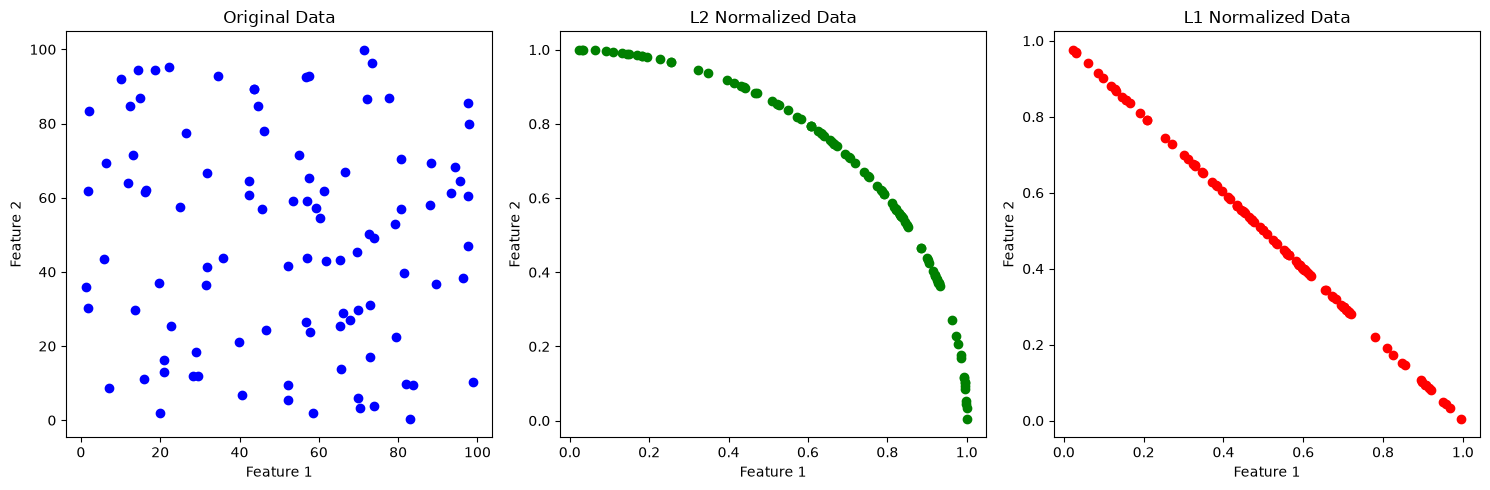

In [4]:
# Plotting the original, L2 normalized, and L1 normalized data

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Original Data
ax[0].scatter(X_toy[:, 0], X_toy[:, 1], color='blue')
ax[0].set_title('Original Data')
ax[0].set_xlabel('Feature 1')
ax[0].set_ylabel('Feature 2')

# L2 Normalized Data
ax[1].scatter(X_l2_normalized[:, 0], X_l2_normalized[:, 1], color='green')
ax[1].set_title('L2 Normalized Data')
ax[1].set_xlabel('Feature 1')
ax[1].set_ylabel('Feature 2')

# L1 Normalized Data
ax[2].scatter(X_l1_normalized[:, 0], X_l1_normalized[:, 1], color='red')
ax[2].set_title('L1 Normalized Data')
ax[2].set_xlabel('Feature 1')
ax[2].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

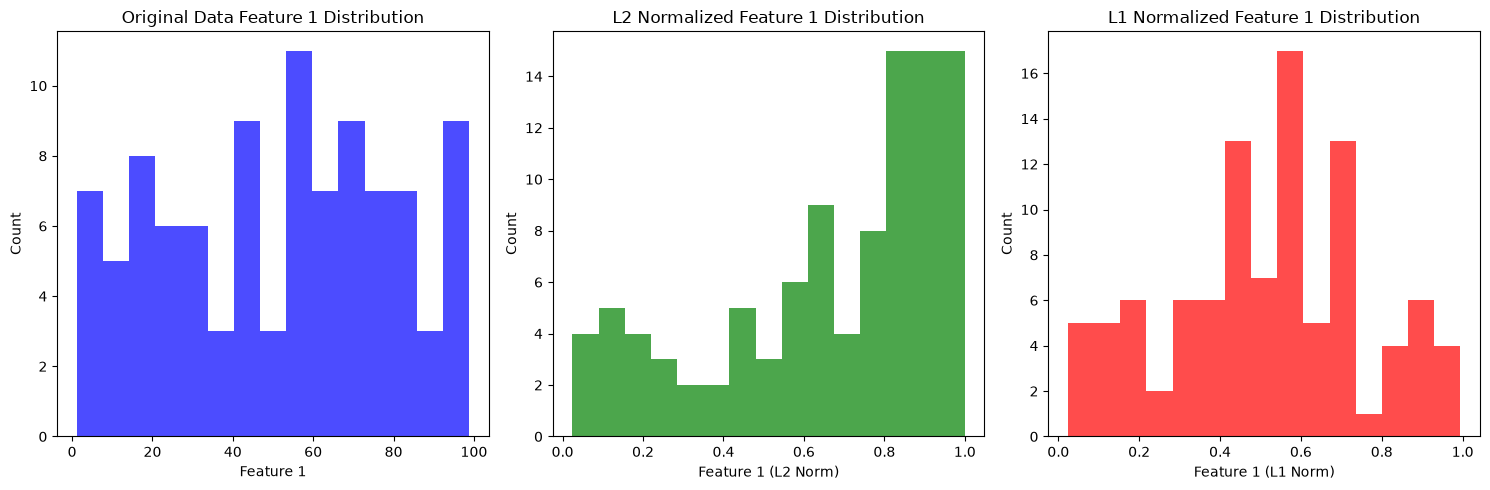

In [5]:
# Plotting the distribution of Feature 1 before and after L2 and L1 normalization

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Original Data Feature 1 Distribution
ax[0].hist(X_toy[:, 0], bins=15, color='blue', alpha=0.7)
ax[0].set_title('Original Data Feature 1 Distribution')
ax[0].set_xlabel('Feature 1')
ax[0].set_ylabel('Count')

# L2 Normalized Data Feature 1 Distribution
ax[1].hist(X_l2_normalized[:, 0], bins=15, color='green', alpha=0.7)
ax[1].set_title('L2 Normalized Feature 1 Distribution')
ax[1].set_xlabel('Feature 1 (L2 Norm)')
ax[1].set_ylabel('Count')

# L1 Normalized Data Feature 1 Distribution
ax[2].hist(X_l1_normalized[:, 0], bins=15, color='red', alpha=0.7)
ax[2].set_title('L1 Normalized Feature 1 Distribution')
ax[2].set_xlabel('Feature 1 (L1 Norm)')
ax[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Effect of Outliers

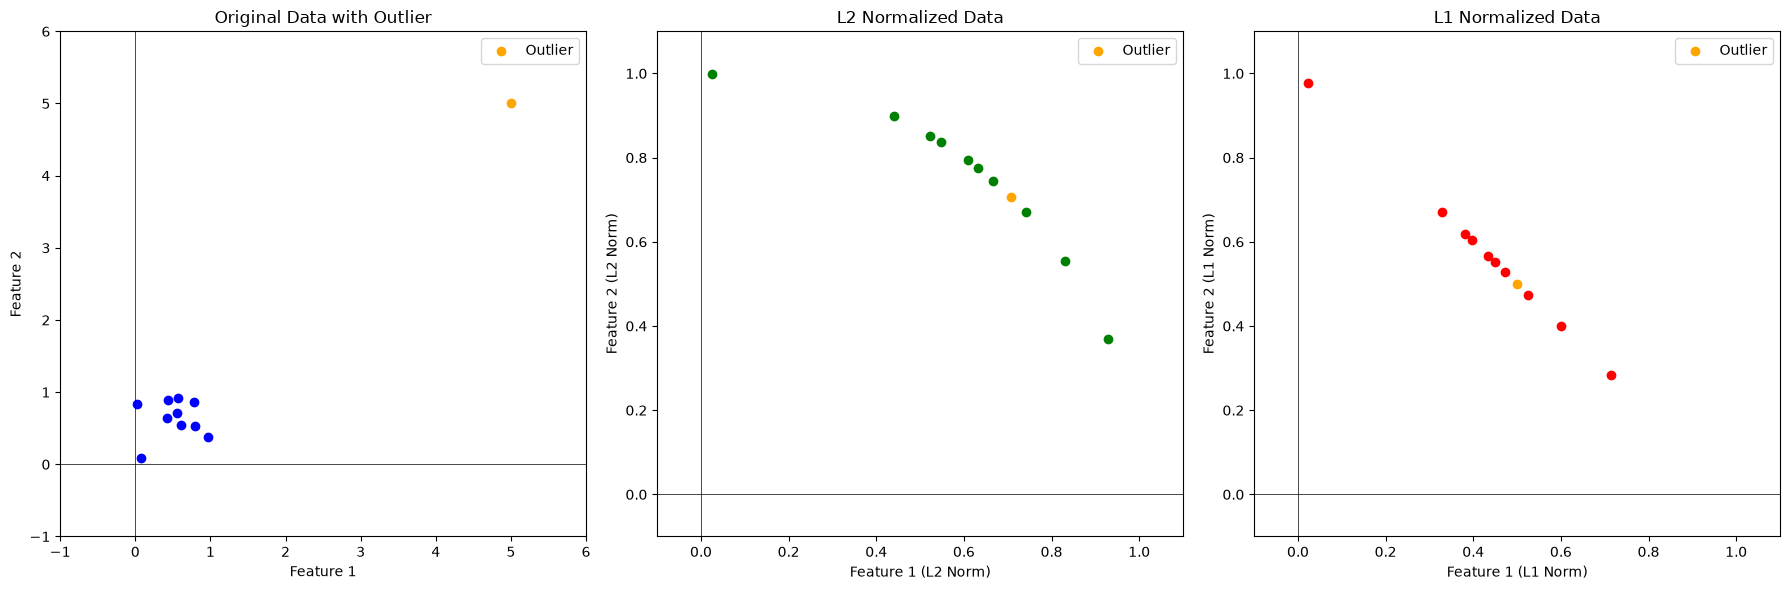

In [6]:
# Creating a new dataset with multiple points and one significant outlier
np.random.seed(0)  # For reproducibility
X_new = np.random.rand(10, 2)  # 10 random points
X_new = np.vstack([X_new, [5, 5]])  # Adding an outlier

# L2 Normalizing the data with the outlier
X_new_l2_normalized = normalize(X_new, norm='l2')

# L1 Normalizing the data with the outlier
X_new_l1_normalized = normalize(X_new, norm='l1')
# Plotting the original, L2 normalized, and L1 normalized data with the outlier highlighted in a different color
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original data with highlighted outlier
axes[0].scatter(X_new[:-1, 0], X_new[:-1, 1], color='blue')
axes[0].scatter(X_new[-1, 0], X_new[-1, 1], color='orange', label='Outlier')
axes[0].set_title('Original Data with Outlier')
axes[0].set_xlim(-1, 6)
axes[0].set_ylim(-1, 6)
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].legend()

# L2 Normalized data with highlighted outlier
axes[1].scatter(X_new_l2_normalized[:-1, 0], X_new_l2_normalized[:-1, 1], color='green')
axes[1].scatter(X_new_l2_normalized[-1, 0], X_new_l2_normalized[-1, 1], color='orange', label='Outlier')
axes[1].set_title('L2 Normalized Data')
axes[1].set_xlim(-0.1, 1.1)
axes[1].set_ylim(-0.1, 1.1)
axes[1].set_xlabel('Feature 1 (L2 Norm)')
axes[1].set_ylabel('Feature 2 (L2 Norm)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].legend()

# L1 Normalized data with highlighted outlier
axes[2].scatter(X_new_l1_normalized[:-1, 0], X_new_l1_normalized[:-1, 1], color='red')
axes[2].scatter(X_new_l1_normalized[-1, 0], X_new_l1_normalized[-1, 1], color='orange', label='Outlier')
axes[2].set_title('L1 Normalized Data')
axes[2].set_xlim(-0.1, 1.1)
axes[2].set_ylim(-0.1, 1.1)
axes[2].set_xlabel('Feature 1 (L1 Norm)')
axes[2].set_ylabel('Feature 2 (L1 Norm)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].axvline(0, color='black', linewidth=0.5)
axes[2].legend()

plt.tight_layout()
plt.show()